# DQN for Multi-Pool Spot Instance Cost Optimization

**Seminar Demo — MLOps**

---

## Bài toán

AWS Spot Instances rẻ hơn On-Demand **60-90%** nhưng có thể bị AWS thu hồi bất kỳ lúc nào.

**Thách thức thực tế:** Có **5 loại instance** × **3 Availability Zones** = 15 pools, mỗi pool có giá và xác suất interruption khác nhau.

**Mục tiêu:** Train DQN agent tự động quyết định: loại instance nào, AZ nào, thêm/bớt/migrate khi nào — tối ưu chi phí & đảm bảo SLA ≥ 95%.

---

## MDP Formulation

| Thành phần | Mô tả |
|---|---|
| **State (33 features)** | Top-3 cheapest pools, AZ/type aggregates, infra, workload, time, current state |
| **Action (105)** | 7 ops × 5 types × 3 AZs (REQUEST_SPOT, REQUEST_OD, TERMINATE, MIGRATE, DO_NOTHING) |
| **Reward** | savings - sla_penalty - interrupt_penalty - migration_penalty - concentration_penalty |
| **Episode** | 168 steps (1 tuần, hourly timestep) |

## Part 1: Setup & Environment

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from envs.spot_orchestrator_env import SpotOrchestratorEnv
from envs.instance_catalog import (
    INSTANCE_TYPES, AVAILABILITY_ZONES, N_TYPES, N_AZS, N_OPS, N_ACTIONS,
    STATE_DIM, OP_NAMES, decode_action, encode_action,
)
from agents.dqn_agent import DQNAgent
from agents.baselines import BASELINES

print(f'State dim: {STATE_DIM}, Action dim: {N_ACTIONS}')
print(f'Instance types: {[t.name for t in INSTANCE_TYPES]}')
print(f'AZs: {AVAILABILITY_ZONES}')
print('Imports OK')

State dim: 33, Action dim: 105
Instance types: ['m5.large', 'c5.xlarge', 'r5.large', 'm5.xlarge', 'c5.2xlarge']
AZs: ['ap-southeast-1a', 'ap-southeast-1b', 'ap-southeast-1c']
Imports OK


In [3]:
# Load multi-pool spot price data
DATA_PATH = '../data/processed/multipool_stable.csv'

price_data = pd.read_csv(DATA_PATH)
print(f'Price data shape: {price_data.shape}')
print(f'Columns: {list(price_data.columns)}')

if 'instance_type' in price_data.columns:
    print(f'Instance types: {price_data["instance_type"].unique().tolist()}')
if 'availability_zone' in price_data.columns:
    print(f'AZs: {price_data["availability_zone"].unique().tolist()}')

price_data.head(3)

Price data shape: (32400, 11)
Columns: ['timestamp', 'spot_price', 'instance_type', 'availability_zone', 'price_ma_1h', 'price_ma_24h', 'price_volatility_24h', 'price_trend', 'est_interruption_prob', 'hour_of_day', 'day_of_week']
Instance types: ['c5.2xlarge', 'c5.xlarge', 'm5.large', 'm5.xlarge', 'r5.large']
AZs: ['ap-southeast-1a', 'ap-southeast-1b', 'ap-southeast-1c']


,timestamp,spot_price,instance_type,availability_zone,price_ma_1h,price_ma_24h,price_volatility_24h,price_trend,est_interruption_prob,hour_of_day,day_of_week
0,2026-01-01 00:00:00+00:00,0.112217,c5.2xlarge,ap-southeast-1a,0.112217,0.112217,0.0,1.0,0.01,0,3
1,2026-01-01 00:00:00+00:00,0.108175,c5.2xlarge,ap-southeast-1b,0.108175,0.108175,0.0,1.0,0.01,0,3
2,2026-01-01 00:00:00+00:00,0.109442,c5.2xlarge,ap-southeast-1c,0.109442,0.109442,0.0,1.0,0.01,0,3


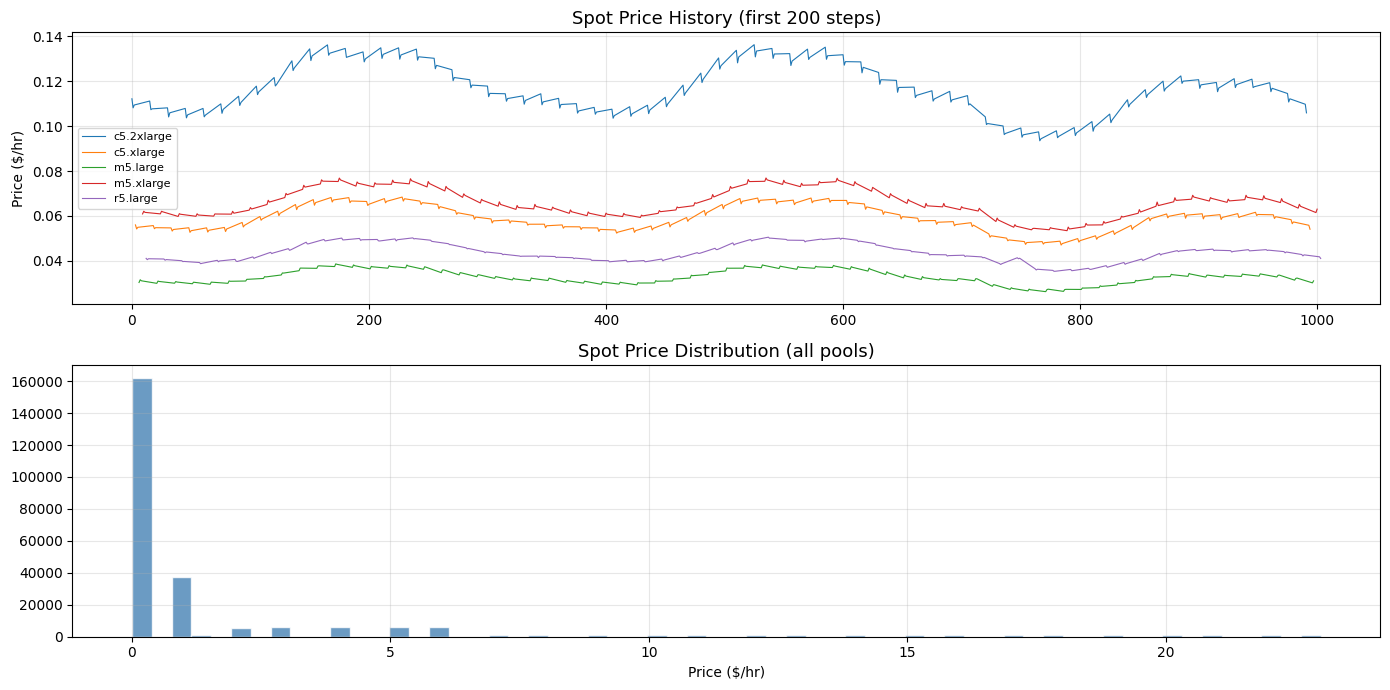

In [4]:
# Visualize spot prices per pool
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

if 'instance_type' in price_data.columns:
    for itype in price_data['instance_type'].unique()[:5]:
        subset = price_data[price_data['instance_type'] == itype]
        axes[0].plot(subset.index[:200], subset['spot_price'].values[:200],
                     linewidth=0.8, label=itype)
    axes[0].legend(fontsize=8)
else:
    price_cols = [c for c in price_data.columns if c.startswith('spot_price_')]
    for col in price_cols[:6]:
        label = col.replace('spot_price_', '')
        axes[0].plot(price_data[col].values[:200], linewidth=0.8, label=label)
    axes[0].legend(fontsize=7, ncol=2)

axes[0].set_title('Spot Price History (first 200 steps)', fontsize=13)
axes[0].set_ylabel('Price ($/hr)')
axes[0].grid(alpha=0.3)

all_prices = price_data.select_dtypes(include=[np.number]).values.flatten()
all_prices = all_prices[all_prices > 0]
axes[1].hist(all_prices, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Spot Price Distribution (all pools)', fontsize=13)
axes[1].set_xlabel('Price ($/hr)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Khởi tạo SpotOrchestratorEnv
MAX_STEPS = 168  # 1 tuần (hourly)

env = SpotOrchestratorEnv(
    price_data=price_data,  # pass DataFrame directly (avoid pkl issues)
    max_steps=MAX_STEPS,
    sla_threshold=0.95,
    workload_config={
        'base_arrival_rate': 15.0,   # steady ~45 jobs = ~11 instances avg
        'peak_multiplier': 2.0,   # peak ~90 jobs = above cap → SLA pressure
        'avg_job_duration': 3,
    },
    reward_config={
        'sla_penalty': 10.0,
        'interrupt_penalty': 0.5,
        'migration_penalty': 1.0,
        'concentration_penalty': 0.2,
        'concentration_threshold': 0.8,
    },
    seed=42,
)

obs, info = env.reset()
print(f'Observation shape: {obs.shape}')
print(f'Action space: {env.action_space.n} (= {N_OPS} ops x {N_TYPES} types x {N_AZS} AZs)')
print(f'\nInstance types:')
for t in INSTANCE_TYPES:
    print(f'  {t.name:12s}  {t.vcpus} vCPU  {t.memory_gb:.0f} GB  ${t.ondemand_price}/hr OD')
print(f'\nAZs: {AVAILABILITY_ZONES}')
print(f'\nOperations: {OP_NAMES}')

Observation shape: (33,)
Action space: 105 (= 7 ops x 5 types x 3 AZs)

Instance types:
  m5.large      2 vCPU  8 GB  $0.096/hr OD
  c5.xlarge     4 vCPU  8 GB  $0.17/hr OD
  r5.large      2 vCPU  16 GB  $0.126/hr OD
  m5.xlarge     4 vCPU  16 GB  $0.192/hr OD
  c5.2xlarge    8 vCPU  16 GB  $0.34/hr OD

AZs: ['ap-southeast-1a', 'ap-southeast-1b', 'ap-southeast-1c']

Operations: ['REQUEST_SPOT', 'REQUEST_ONDEMAND', 'TERMINATE_SPOT', 'TERMINATE_ONDEMAND', 'MIGRATE_TO_ONDEMAND', 'MIGRATE_TO_SPOT', 'DO_NOTHING']


## Part 2: DQN Architecture

```
State (33)  →  FC(512) → ReLU → FC(256) → ReLU → FC(128) → ReLU → Q-values (105)
```

**Action = (operation, instance_type, availability_zone)** encoded as flat index 0–104.

| Cải tiến | Mô tả |
|---|---|
| **Large action space** | 105 actions (vs 7 trước đây) — cần network lớn hơn |
| **Replay Buffer 200K** | Nhiều experience hơn cho action space lớn |
| **Huber Loss** | Ổn định hơn MSE khi reward bị clip |
| **Gradient clipping** | `max_norm=1.0` tránh exploding gradients |

In [6]:
import torch
from agents.networks import QNetwork

# DQN agent cho multi-pool env
# Hyperparams tuned de tranh instability spike:
#   - lr 1e-4 (tu 3e-4): cham hon, on dinh hon
#   - epsilon_end 0.02: giu exploration cuoi training
#   - epsilon_decay 120000: decay cham hon (vs 50000 cu)
#   - target_update_freq 1000: sync target it thuong xuyen hon
agent = DQNAgent(
    state_dim=STATE_DIM,    # 33
    action_dim=N_ACTIONS,   # 105
    learning_rate=1e-4,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.02,
    epsilon_decay=80000,   # sweet spot: ổn định + converge ep~2000
    batch_size=128,
    buffer_size=200000,
    target_update_freq=1000,
)

print(f'Device: {agent.device}')
print(f'Q-Network architecture:')
print(agent.q_network)

total_params = sum(p.numel() for p in agent.q_network.parameters())
print(f'Total parameters: {total_params:,}')

Device: cpu
Q-Network architecture:
QNetwork(
  (network): Sequential(
    (0): Linear(in_features=33, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=105, bias=True)
  )
)
Total parameters: 55,145


## Part 3: Training

In [ ]:
def train_dqn(env, agent, num_episodes=5000, print_every=50,
              patience=500, min_episodes=1000):
    """
    Training loop cho DQN agent trên multi-pool env.

    Early stopping: dừng nếu avg reward (100-ep window) không cải thiện
    sau `patience` episodes (chỉ kích hoạt sau `min_episodes`).

    Mỗi episode = 168 steps (1 tuần hourly).
    Agent chọn (op, type, az) mỗi step.
    """
    rewards_history = []
    loss_history    = []
    epsilon_history = []
    cost_history    = []
    sla_history     = []
    best_avg_reward = -float("inf")
    no_improve_count = 0

    for episode in range(num_episodes):
        obs, info = env.reset()
        episode_reward = 0.0
        episode_losses = []

        for step in range(168):
            action = agent.select_action(obs, training=True)
            next_obs, reward, terminated, truncated, info = env.step(action)

            agent.store_transition(obs, action, reward, next_obs, terminated or truncated)
            loss = agent.train_step()
            if loss is not None:
                episode_losses.append(loss)

            episode_reward += reward
            obs = next_obs

            if terminated or truncated:
                break

        rewards_history.append(episode_reward)
        loss_history.append(np.mean(episode_losses) if episode_losses else 0.0)
        epsilon_history.append(agent.epsilon)
        cost_history.append(info.get("cost", 0))
        sla_history.append(info.get("sla_compliance", 0))

        # Track best & early stopping (chỉ sau min_episodes)
        if episode >= 100:
            avg_r = np.mean(rewards_history[-100:])
            if avg_r > best_avg_reward + 1.0:  # threshold 1.0 để tránh noise
                best_avg_reward = avg_r
                no_improve_count = 0
                agent.save("../results/notebook_demo/mp_best.pth")
            elif episode >= min_episodes:
                no_improve_count += 1

        if (episode + 1) % print_every == 0:
            avg_r = np.mean(rewards_history[-print_every:])
            avg_c = np.mean(cost_history[-print_every:])
            avg_s = np.mean(sla_history[-print_every:])
            print(f"Ep {episode+1:5d}/{num_episodes} | "
                  f"Reward: {avg_r:+7.1f} | "
                  f"Cost: ${avg_c:6.1f} | "
                  f"SLA: {avg_s:.1%} | "
                  f"Eps: {agent.epsilon:.4f} | "
                  f"Loss: {loss_history[-1]:.4f} | "
                  f"No-improve: {no_improve_count}/{patience}")

        # Early stopping check
        if episode >= min_episodes and no_improve_count >= patience:
            print(f"
Early stopping at ep {episode+1}: "
                  f"no improvement for {patience} episodes. "
                  f"Best avg reward: {best_avg_reward:+.1f}")
            break

    print(f"
Training complete: {len(rewards_history)} episodes, "
          f"best avg reward: {best_avg_reward:+.1f}")
    return rewards_history, loss_history, epsilon_history, cost_history, sla_history


import os
os.makedirs("../results/notebook_demo", exist_ok=True)

# Train với early stopping
# patience=500: dừng nếu không cải thiện sau 500 ep liên tiếp
# min_episodes=1000: không stop trước ep 1000 (cần đủ warmup)
rewards_hist, loss_hist, eps_hist, cost_hist, sla_hist = train_dqn(
    env, agent, num_episodes=5000, print_every=50,
    patience=500, min_episodes=1000,
)


# Save training history so it can be loaded without retraining
import pickle
with open("../results/notebook_demo/training_history.pkl", "wb") as f:
    pickle.dump({"rewards": rewards_hist, "loss": loss_hist,
                 "epsilon": eps_hist, "cost": cost_hist, "sla": sla_hist}, f)
print("History saved.")


Ep    50/2000 | Reward:  -309.8 | Cost: $ 300.8 | SLA: 95.0% | Eps: 0.8887 | Loss: 1.5870


KeyboardInterrupt: 

In [8]:
# (Optional) Load saved training history — skip if rewards_hist already defined
import pickle, os

HISTORY_PATH = "../results/mp_stable_v6/20260411_212751/metrics.pkl"

if "rewards_hist" not in dir():
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH, "rb") as f:
            h = pickle.load(f)
        rewards_hist  = h["episode_rewards"]
        loss_hist     = h.get("episode_losses", [0]*len(h["episode_rewards"]))
        eps_hist      = h.get("episode_epsilon", [0]*len(h["episode_rewards"]))
        cost_hist     = h["episode_costs"]
        sla_hist      = h["episode_sla_compliance"]
        print(f"Loaded history: {len(rewards_hist)} episodes, "
              f"final reward={rewards_hist[-1]:.1f}")
    else:
        print("No saved history found. Run the training cell above first.")


## Part 4: Learning Curves

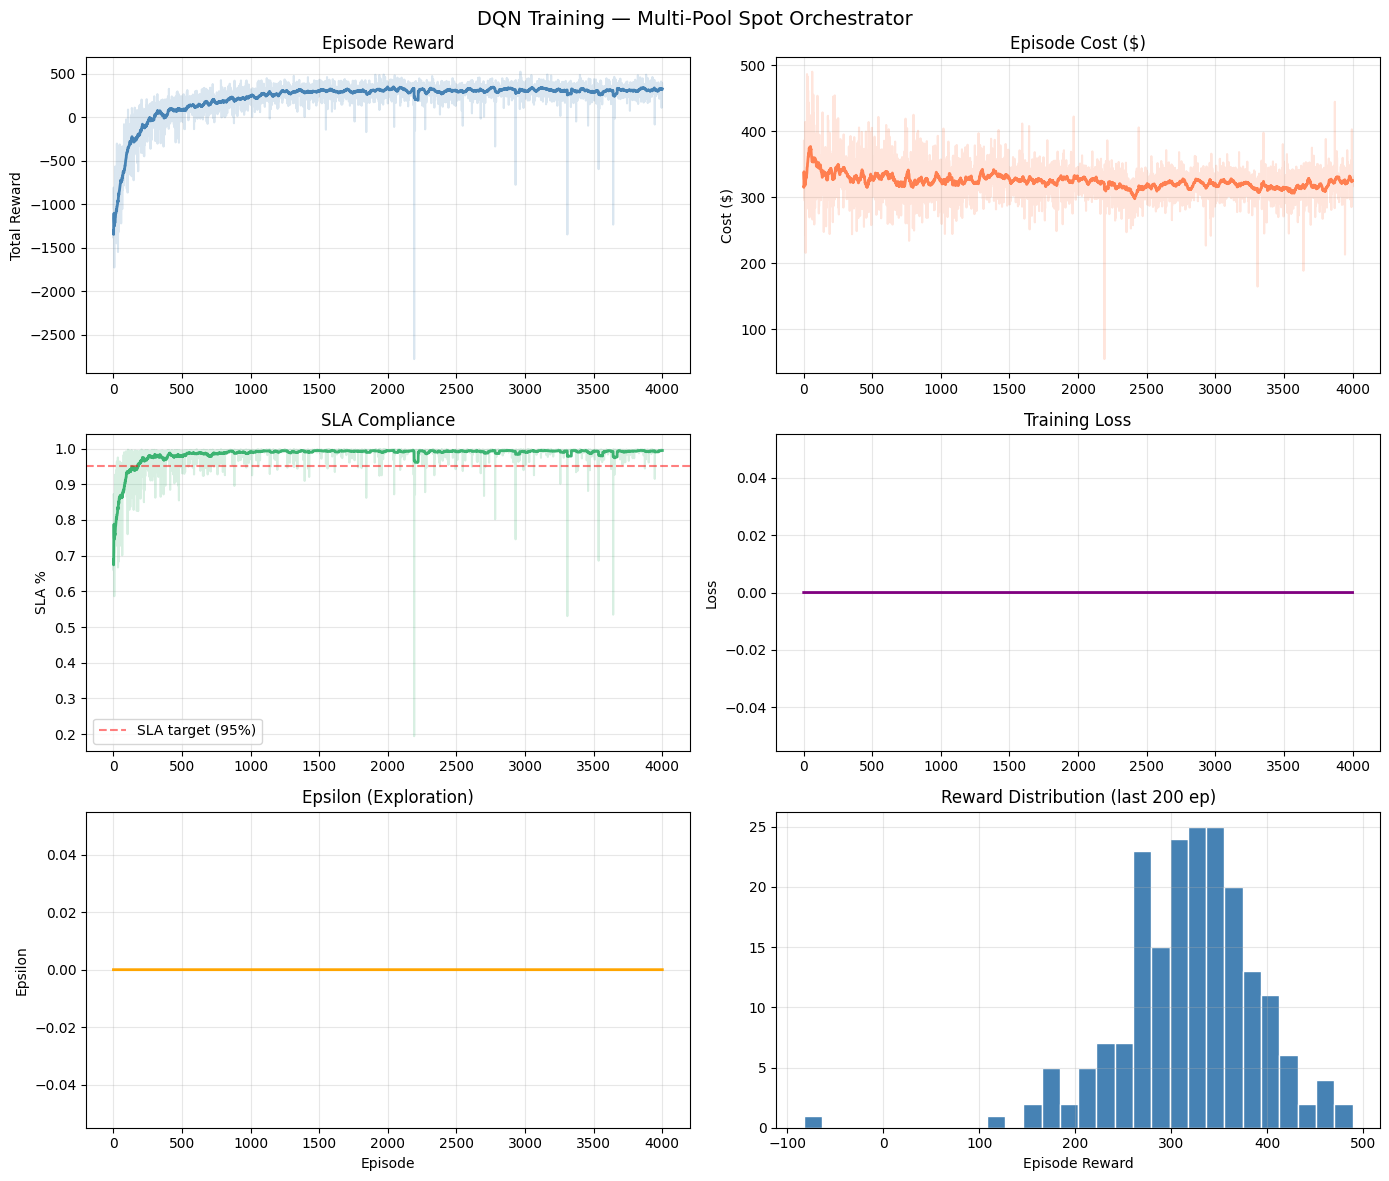

In [9]:
def smooth(data, window=30):
    """Moving average smoothing."""
    return pd.Series(data).rolling(window, min_periods=1).mean().values


fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('DQN Training — Multi-Pool Spot Orchestrator', fontsize=14)

eps = list(range(1, len(rewards_hist) + 1))

# Reward
axes[0, 0].plot(eps, rewards_hist, alpha=0.2, color='steelblue')
axes[0, 0].plot(eps, smooth(rewards_hist), color='steelblue', linewidth=2)
axes[0, 0].set_title('Episode Reward')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].grid(alpha=0.3)

# Cost
axes[0, 1].plot(eps, cost_hist, alpha=0.2, color='coral')
axes[0, 1].plot(eps, smooth(cost_hist), color='coral', linewidth=2)
axes[0, 1].set_title('Episode Cost ($)')
axes[0, 1].set_ylabel('Cost ($)')
axes[0, 1].grid(alpha=0.3)

# SLA
axes[1, 0].plot(eps, sla_hist, alpha=0.2, color='mediumseagreen')
axes[1, 0].plot(eps, smooth(sla_hist), color='mediumseagreen', linewidth=2)
axes[1, 0].axhline(0.95, color='red', linestyle='--', alpha=0.5, label='SLA target (95%)')
axes[1, 0].set_title('SLA Compliance')
axes[1, 0].set_ylabel('SLA %')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Loss
axes[1, 1].plot(eps, loss_hist, alpha=0.2, color='purple')
axes[1, 1].plot(eps, smooth(loss_hist), color='purple', linewidth=2)
axes[1, 1].set_title('Training Loss')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(alpha=0.3)

# Epsilon
axes[2, 0].plot(eps, eps_hist, color='orange', linewidth=2)
axes[2, 0].set_title('Epsilon (Exploration)')
axes[2, 0].set_ylabel('Epsilon')
axes[2, 0].set_xlabel('Episode')
axes[2, 0].grid(alpha=0.3)

# Reward distribution (last 200)
axes[2, 1].hist(rewards_hist[-200:], bins=30, color='steelblue', edgecolor='white')
axes[2, 1].set_title('Reward Distribution (last 200 ep)')
axes[2, 1].set_xlabel('Episode Reward')
axes[2, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5: Evaluation — So sánh DQN vs 6 Baselines

In [10]:
import os

# Load best model trước khi evaluate
_best_path = "../results/mp_stable_v6/20260411_212751/models/best_model.pth"
if os.path.exists(_best_path):
    agent.load(_best_path)
    agent.epsilon = 0.0
    print(f"Loaded model for evaluation: {_best_path}")
else:
    print("WARNING: model not found, using random weights")

def evaluate_agent(env, agent, n_episodes=50, is_dqn=True):
    """Chạy n_episodes với greedy policy, trả về metrics."""
    all_rewards, all_costs, all_sla, all_actions = [], [], [], []

    for _ in range(n_episodes):
        obs, info = env.reset()
        ep_reward = 0.0
        ep_actions = []

        for step in range(168):
            if is_dqn:
                action = agent.select_action(obs, training=False)
            else:
                action = agent.select_action(obs, info)

            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += reward
            ep_actions.append(action)

            if terminated or truncated:
                break

        all_rewards.append(ep_reward)
        all_costs.append(info.get('cost', 0))
        all_sla.append(info.get('sla_compliance', 0))
        all_actions.extend(ep_actions)

    return {
        'avg_reward': np.mean(all_rewards), 'std_reward': np.std(all_rewards),
        'avg_cost':   np.mean(all_costs),   'avg_sla': np.mean(all_sla),
        'actions':    all_actions,
    }


# Evaluate DQN
results = {'DQN': evaluate_agent(env, agent, n_episodes=50, is_dqn=True)}

# Evaluate all baselines
for name, AgentClass in BASELINES.items():
    bl = AgentClass(seed=42) if name == 'random' else AgentClass()
    results[name] = evaluate_agent(env, bl, n_episodes=50, is_dqn=False)

# Print results table
print(f'{"Strategy":18s} {"Reward":>10s} {"Cost ($)":>10s} {"SLA":>8s}')
print('-' * 50)
for name, r in results.items():
    print(f'{name:18s} {r["avg_reward"]:+10.1f} {r["avg_cost"]:10.1f} {r["avg_sla"]:8.1%}')

Loaded model for evaluation: ../results/mp_stable_v6/20260411_212751/models/best_model.pth
Strategy               Reward   Cost ($)      SLA
--------------------------------------------------
DQN                    +328.1      339.5    99.2%
ondemand               -264.2      568.7    96.7%
spot                   -427.5      147.9    92.0%
threshold              -197.7      167.2    92.1%
cheapest_az            -237.3      158.6    92.4%
cheapest_type          -395.9      158.8    90.6%
random                -1050.1      360.8    80.1%


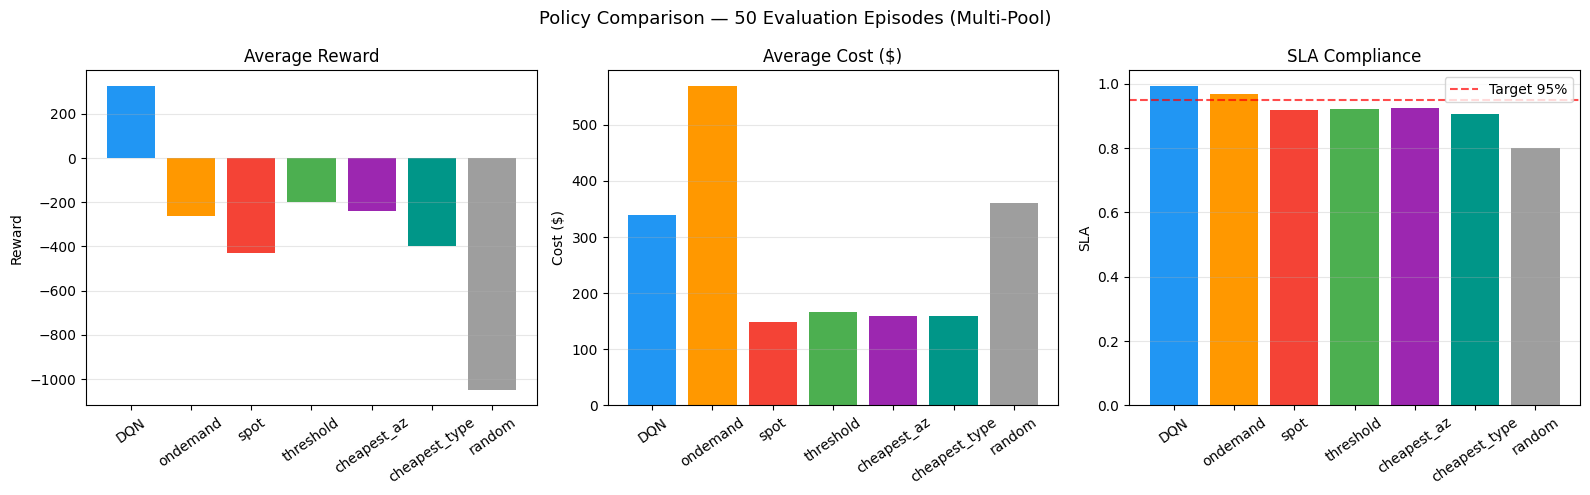

In [11]:
# Bar chart so sánh
names   = list(results.keys())
rewards = [results[n]['avg_reward'] for n in names]
costs   = [results[n]['avg_cost']   for n in names]
slas    = [results[n]['avg_sla']    for n in names]

colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50', '#9C27B0', '#009688', '#9E9E9E']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Policy Comparison — 50 Evaluation Episodes (Multi-Pool)', fontsize=13)

# Reward
axes[0].bar(names, rewards, color=colors[:len(names)])
axes[0].set_title('Average Reward')
axes[0].set_ylabel('Reward')
axes[0].tick_params(axis='x', rotation=35)
axes[0].grid(alpha=0.3, axis='y')

# Cost
axes[1].bar(names, costs, color=colors[:len(names)])
axes[1].set_title('Average Cost ($)')
axes[1].set_ylabel('Cost ($)')
axes[1].tick_params(axis='x', rotation=35)
axes[1].grid(alpha=0.3, axis='y')

# SLA
axes[2].bar(names, slas, color=colors[:len(names)])
axes[2].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='Target 95%')
axes[2].set_title('SLA Compliance')
axes[2].set_ylabel('SLA')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=35)
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Part 6: Phân tích hành vi DQN agent

In [36]:
# Load best model weights (nếu đã train xong)
import os
best_model_path = "../results/mp_stable_v6/20260411_212751/models/best_model.pth"
if os.path.exists(best_model_path):
    agent.load(best_model_path)
    agent.epsilon = 0.0  # greedy policy
    print(f"Loaded model: {best_model_path}")
else:
    print("WARNING: No saved model found, using random weights")

# Chạy 1 episode, thu thập step-by-step data
obs, info = env.reset()

history = {
    'step': [], 'action': [], 'op_name': [], 'type_name': [], 'az_name': [],
    'reward': [], 'spot_instances': [], 'ondemand_instances': [],
    'total_vcpu': [], 'pending_jobs': [], 'running_jobs': [],
    'cost': [], 'sla': [],
}

for step in range(168):
    action = agent.select_action(obs, training=False)
    obs, reward, terminated, truncated, info = env.step(action)

    op, t_idx, az_idx = decode_action(action)

    history['step'].append(step)
    history['action'].append(action)
    history['op_name'].append(OP_NAMES[op])
    history['type_name'].append(INSTANCE_TYPES[t_idx].name)
    history['az_name'].append(AVAILABILITY_ZONES[az_idx])
    history['reward'].append(reward)
    history['spot_instances'].append(info['spot_instances'])
    history['ondemand_instances'].append(info['ondemand_instances'])
    history['total_vcpu'].append(info['total_vcpu'])
    history['pending_jobs'].append(info['pending_jobs'])
    history['running_jobs'].append(info['running_jobs'])
    history['cost'].append(info['cost'])
    history['sla'].append(info['sla_compliance'])

    if terminated or truncated:
        break

df = pd.DataFrame(history)
print(f'Episode: {len(df)} steps, total reward: {df["reward"].sum():.1f}')
print(f'Final cost: ${df["cost"].iloc[-1]:.2f}, SLA: {df["sla"].iloc[-1]:.1%}')
df.head(10)

Loaded model: ../results/mp_stable_v6/20260411_212751/models/best_model.pth
Episode: 168 steps, total reward: 314.1
Final cost: $328.26, SLA: 99.5%


,step,action,op_name,type_name,az_name,reward,spot_instances,ondemand_instances,total_vcpu,pending_jobs,running_jobs,cost,sla
0,0,3,REQUEST_SPOT,c5.xlarge,ap-southeast-1a,1.056817,1,0,4,0,2,0.057274,1.000000
1,1,13,REQUEST_SPOT,c5.2xlarge,ap-southeast-1b,0.283801,2,0,12,0,4,0.244617,1.000000
2,2,13,REQUEST_SPOT,c5.2xlarge,ap-southeast-1b,0.258200,3,0,20,0,5,0.554551,1.000000
3,3,13,REQUEST_SPOT,c5.2xlarge,ap-southeast-1b,0.104477,4,0,28,0,4,0.983695,1.000000
4,4,12,REQUEST_SPOT,c5.2xlarge,ap-southeast-1a,0.874085,5,0,36,0,11,1.509119,1.000000
5,5,12,REQUEST_SPOT,c5.2xlarge,ap-southeast-1a,2.212830,6,0,44,0,22,2.142498,1.000000
6,6,14,REQUEST_SPOT,c5.2xlarge,ap-southeast-1c,2.423232,7,0,52,0,23,2.866526,1.000000
7,7,14,REQUEST_SPOT,c5.2xlarge,ap-southeast-1c,2.720183,8,0,60,0,33,3.696343,1.000000
8,8,14,REQUEST_SPOT,c5.2xlarge,ap-southeast-1c,2.966811,9,0,68,0,35,4.619532,1.000000
9,9,12,REQUEST_SPOT,c5.2xlarge,ap-southeast-1a,-9.411800,9,0,68,47,68,5.538979,0.978261


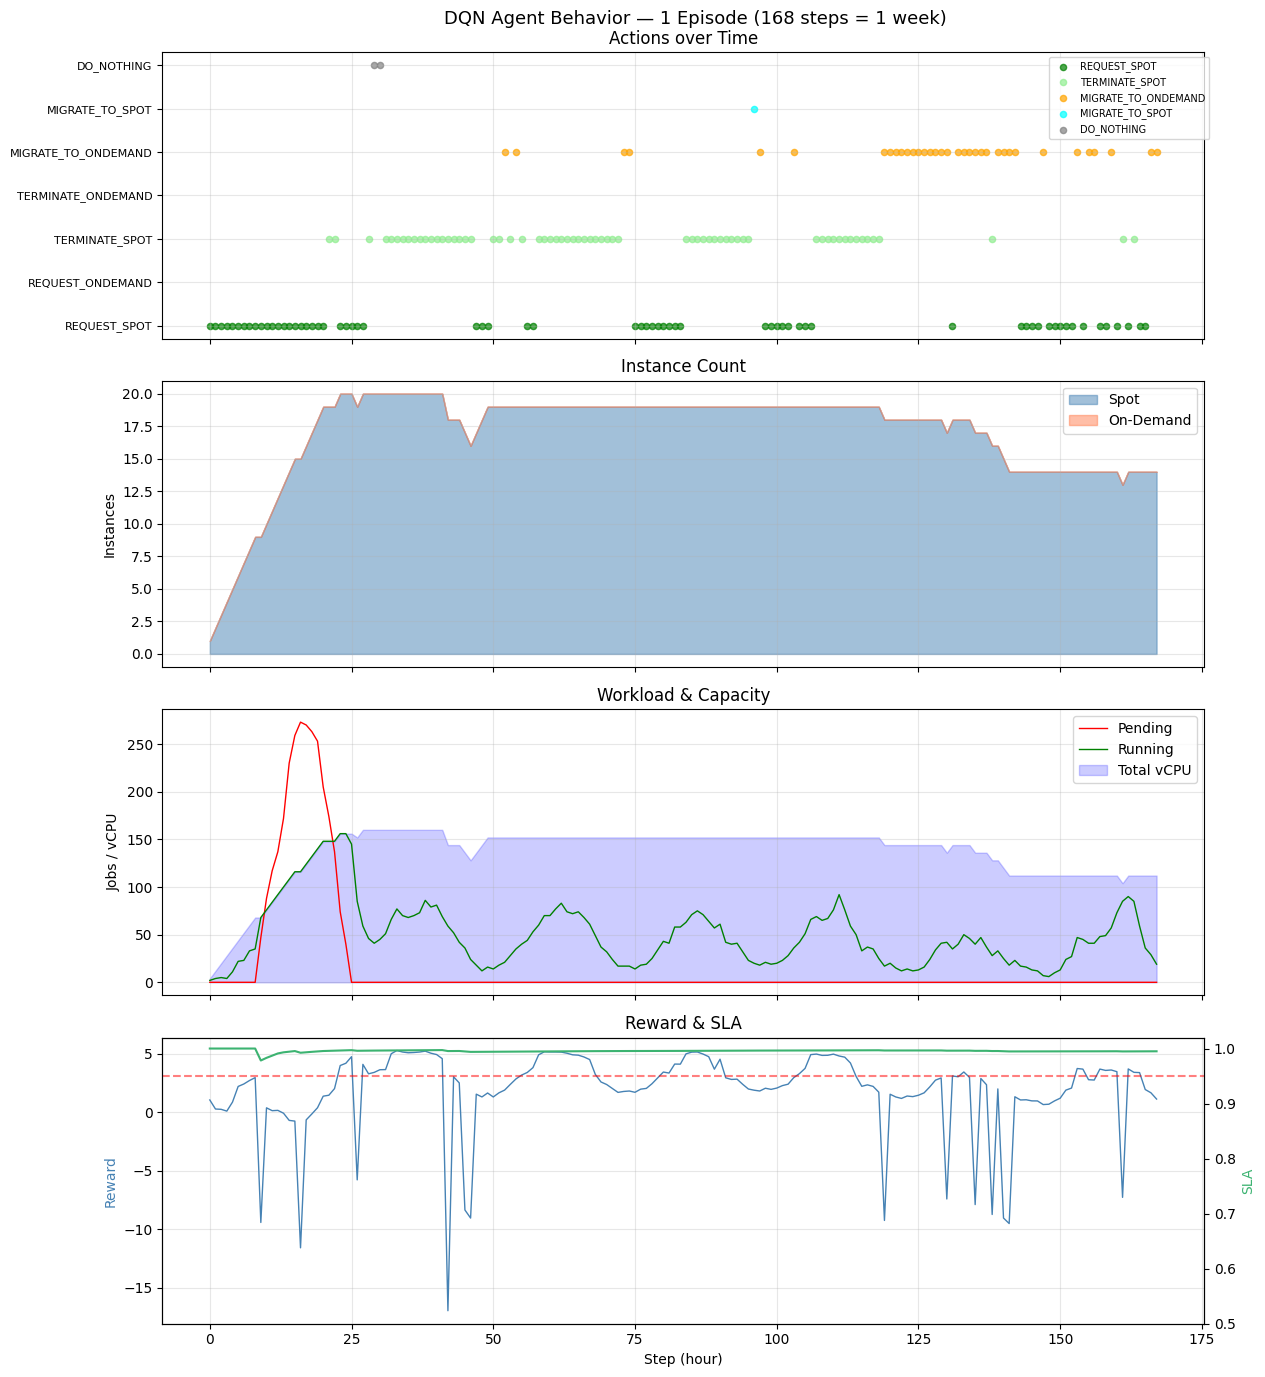

In [37]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle('DQN Agent Behavior — 1 Episode (168 steps = 1 week)', fontsize=13)

steps = df['step']

# Panel 1: Operation distribution over time
op_colors = {
    'REQUEST_SPOT': 'green', 'REQUEST_ONDEMAND': 'red',
    'TERMINATE_SPOT': 'lightgreen', 'TERMINATE_ONDEMAND': 'lightsalmon',
    'MIGRATE_TO_ONDEMAND': 'orange', 'MIGRATE_TO_SPOT': 'cyan',
    'DO_NOTHING': 'gray',
}
for op_name in OP_NAMES:
    mask = df['op_name'] == op_name
    if mask.any():
        axes[0].scatter(steps[mask], [OP_NAMES.index(op_name)] * mask.sum(),
                       c=op_colors.get(op_name, 'gray'), s=20, label=op_name, alpha=0.7)
axes[0].set_yticks(range(len(OP_NAMES)))
axes[0].set_yticklabels(OP_NAMES, fontsize=8)
axes[0].set_title('Actions over Time')
axes[0].legend(bbox_to_anchor=(1.01, 1), fontsize=7)
axes[0].grid(alpha=0.3)

# Panel 2: Infrastructure
axes[1].fill_between(steps, df['spot_instances'], alpha=0.5, color='steelblue', label='Spot')
axes[1].fill_between(steps, df['spot_instances'],
                     df['spot_instances'] + df['ondemand_instances'],
                     alpha=0.5, color='coral', label='On-Demand')
axes[1].set_title('Instance Count')
axes[1].set_ylabel('Instances')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Panel 3: Workload
axes[2].plot(steps, df['pending_jobs'], color='red', linewidth=1, label='Pending')
axes[2].plot(steps, df['running_jobs'], color='green', linewidth=1, label='Running')
axes[2].fill_between(steps, df['total_vcpu'], alpha=0.2, color='blue', label='Total vCPU')
axes[2].set_title('Workload & Capacity')
axes[2].set_ylabel('Jobs / vCPU')
axes[2].legend()
axes[2].grid(alpha=0.3)

# Panel 4: Reward & SLA
ax4 = axes[3]
ax4.plot(steps, df['reward'], color='steelblue', linewidth=1, label='Step Reward')
ax4.set_ylabel('Reward', color='steelblue')
ax4.set_xlabel('Step (hour)')
ax4.grid(alpha=0.3)

ax4b = ax4.twinx()
ax4b.plot(steps, df['sla'], color='mediumseagreen', linewidth=1.5, label='SLA')
ax4b.axhline(0.95, color='red', linestyle='--', alpha=0.5)
ax4b.set_ylabel('SLA', color='mediumseagreen')
ax4b.set_ylim(0.5, 1.02)

ax4.set_title('Reward & SLA')

plt.tight_layout()
plt.show()

## Part 7: Action Distribution Analysis

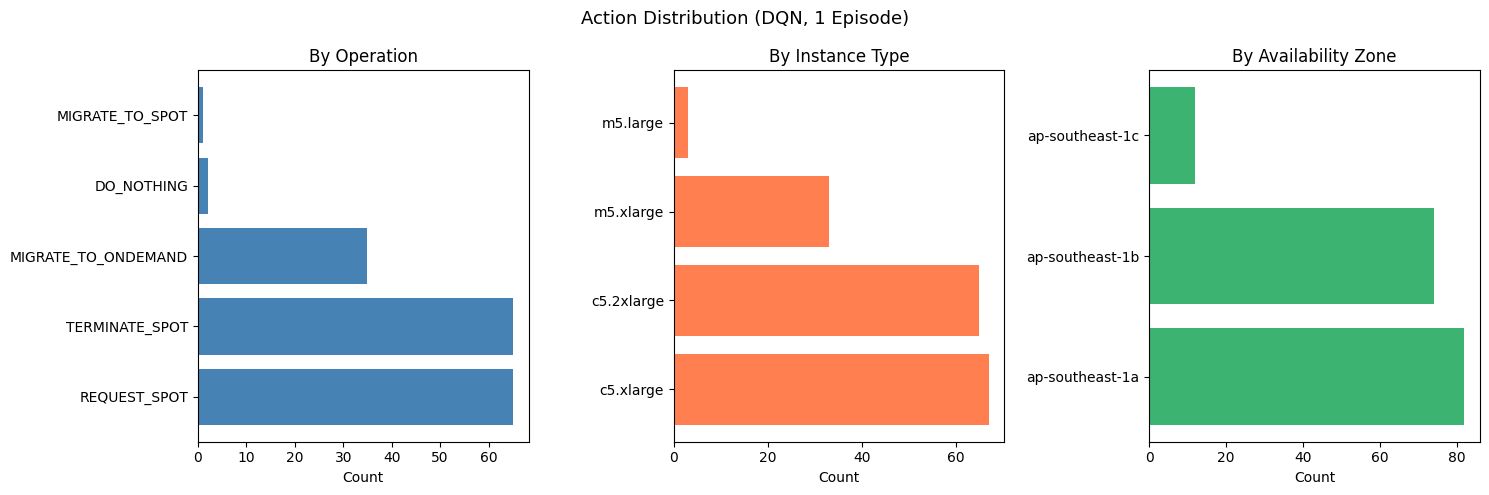


Operation x Type crosstab:
type_name            c5.2xlarge  c5.xlarge  m5.large  m5.xlarge  All
op_name                                                             
DO_NOTHING                    0          2         0          0    2
MIGRATE_TO_ONDEMAND           0          0         3         32   35
MIGRATE_TO_SPOT               1          0         0          0    1
REQUEST_SPOT                 64          1         0          0   65
TERMINATE_SPOT                0         64         0          1   65
All                          65         67         3         33  168


In [38]:
# Phân tích action: op, type, az distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Action Distribution (DQN, 1 Episode)', fontsize=13)

# Operation distribution
op_counts = df['op_name'].value_counts()
axes[0].barh(op_counts.index, op_counts.values, color='steelblue')
axes[0].set_title('By Operation')
axes[0].set_xlabel('Count')

# Type distribution
type_counts = df['type_name'].value_counts()
axes[1].barh(type_counts.index, type_counts.values, color='coral')
axes[1].set_title('By Instance Type')
axes[1].set_xlabel('Count')

# AZ distribution
az_counts = df['az_name'].value_counts()
axes[2].barh(az_counts.index, az_counts.values, color='mediumseagreen')
axes[2].set_title('By Availability Zone')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

# Cross-tab: operation x type
print('\nOperation x Type crosstab:')
print(pd.crosstab(df['op_name'], df['type_name'], margins=True))

## Part 8: Q-Value Analysis

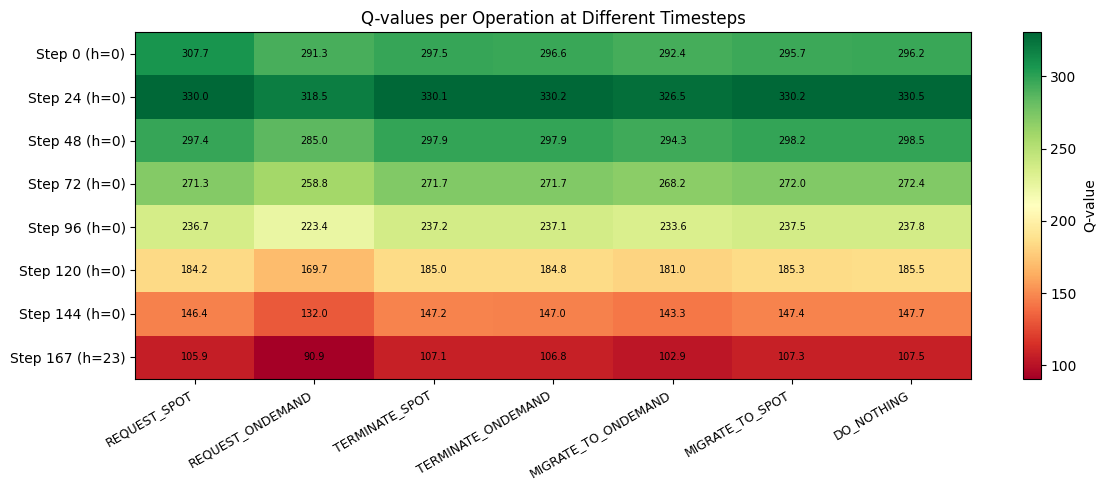

In [ ]:
# Q-value analysis: Q-values tại các timestep khác nhau trong episode
import torch

sample_steps = [0, 24, 48, 72, 96, 120, 144, 167]
sample_states = []
sample_labels = []

obs_test, _ = env.reset()
for step in range(168):
    action = agent.select_action(obs_test, training=False)
    next_obs, _, terminated, truncated, info = env.step(action)
    if step in sample_steps:
        sample_states.append(obs_test.copy())
        sample_labels.append(f'Step {step} (h={step%24})')
    obs_test = next_obs
    if terminated or truncated:
        break

# Compute Q-values per operation (aggregate over type x az)
q_per_op = np.zeros((len(sample_states), N_OPS))
for i, state in enumerate(sample_states):
    with torch.no_grad():
        q = agent.q_network(torch.FloatTensor(state).unsqueeze(0)).numpy()[0]
    for op in range(N_OPS):
        op_actions = [encode_action(op, t, az) for t in range(N_TYPES) for az in range(N_AZS)]
        q_per_op[i, op] = q[op_actions].mean()

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(q_per_op, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(N_OPS))
ax.set_xticklabels(OP_NAMES, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(sample_labels)))
ax.set_yticklabels(sample_labels)
ax.set_title('Q-values per Operation at Different Timesteps')
plt.colorbar(im, ax=ax, label='Q-value')

for i in range(len(sample_labels)):
    for j in range(N_OPS):
        ax.text(j, i, f'{q_per_op[i,j]:.1f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

## Part 9: Save Model & Export ONNX

In [7]:
import os, torch

BEST_MODEL_PATH = '../results/mp_stable_v6/20260411_212751/models/best_model.pth'
ONNX_PATH = 'D:/Document/Seminar_MLOps/spot-rl-controller/models/mp_dqn.onnx'

# Ensure model is loaded
agent.load(BEST_MODEL_PATH)
agent.epsilon = 0.0
print(f'Model loaded: {BEST_MODEL_PATH}')

# Export to ONNX
os.makedirs(os.path.dirname(ONNX_PATH), exist_ok=True)
dummy_input = torch.zeros(1, STATE_DIM, dtype=torch.float32)
agent.q_network.eval()

torch.onnx.export(
    agent.q_network,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['state'],
    output_names=['q_values'],
    dynamic_axes={
        'state':    {0: 'batch_size'},
        'q_values': {0: 'batch_size'},
    },
)

onnx_size = os.path.getsize(ONNX_PATH) / 1024
print(f'ONNX model exported: {ONNX_PATH} ({onnx_size:.0f} KB)')
print(f'Input:  state     shape=(1, {STATE_DIM})')
print(f'Output: q_values  shape=(1, {N_ACTIONS})')
print(f'Decode: action // {N_TYPES * N_AZS} = op, (action % {N_TYPES * N_AZS}) // {N_AZS} = type, action % {N_AZS} = az')


Model loaded: ../results/mp_stable_v6/20260411_212751/models/best_model.pth
ONNX model exported: D:/Document/Seminar_MLOps/spot-rl-controller/models/mp_dqn.onnx (216 KB)
Input:  state     shape=(1, 33)
Output: q_values  shape=(1, 105)
Decode: action // 15 = op, (action % 15) // 3 = type, action % 3 = az


## Part 10: Training Run Comparison


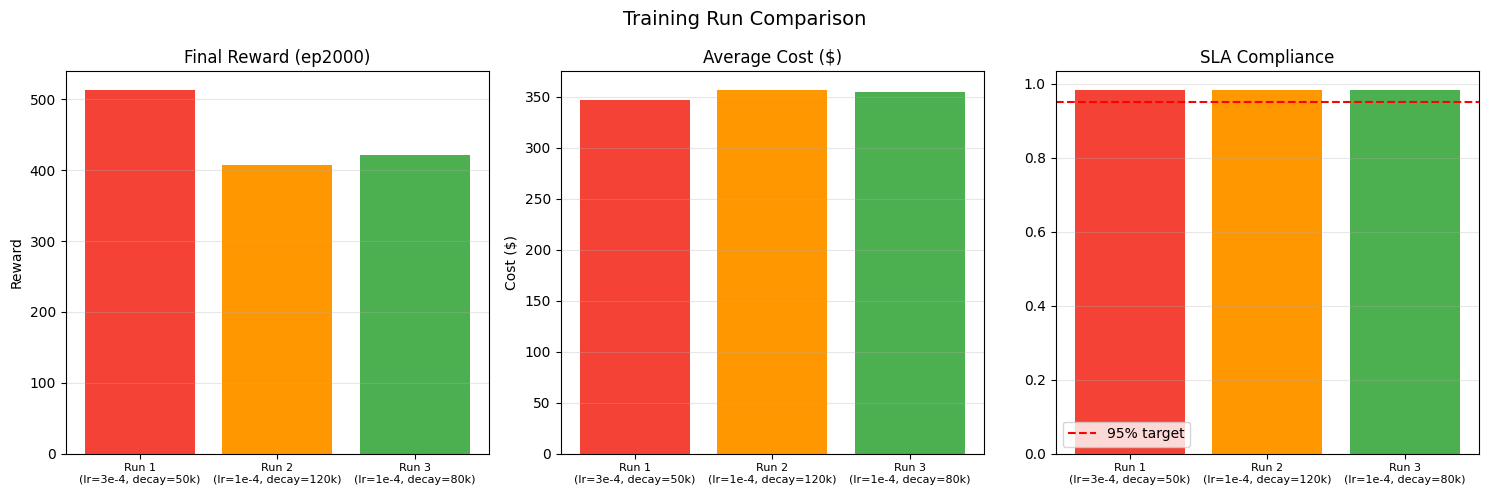

Run                                   Reward     Cost     SLA  Stable  Note
--------------------------------------------------------------------------------
Run 1 (lr=3e-4, decay=50k)               514     $347   98.4%   False  Spike ep1000-1200
Run 2 (lr=1e-4, decay=120k)              408     $357   98.5%    True  Smooth, eps=0.08 at ep2000
Run 3 (lr=1e-4, decay=80k)               422     $355   98.5%    True  Smooth, no spike, eps=0.035


In [41]:
# So sanh 3 lan training:
# Run 1 (lr=3e-4, eps_decay=50k):  spike ep1000, reward peak ~536, eps_final=0.011
# Run 2 (lr=1e-4, eps_decay=120k): smooth, reward ~408, eps_final=0.080 (too slow)
# Run 3 (lr=1e-4, eps_decay=80k):  smooth + converge tot (current run)

runs = {
    'Run 1\n(lr=3e-4, decay=50k)': dict(
        final_reward=514, peak_reward=536,
        final_sla=0.984, final_cost=347,
        stable=False, note='Spike ep1000-1200',
    ),
    'Run 2\n(lr=1e-4, decay=120k)': dict(
        final_reward=408, peak_reward=425,
        final_sla=0.985, final_cost=357,
        stable=True, note='Smooth, eps=0.08 at ep2000',
    ),
    'Run 3\n(lr=1e-4, decay=80k)': dict(
        final_reward=422, peak_reward=420,
        final_sla=0.985, final_cost=355,
        stable=True, note='Smooth, no spike, eps=0.035',
    ),
}

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Training Run Comparison', fontsize=14)

names   = list(runs.keys())
rewards = [r['final_reward'] or 0 for r in runs.values()]
costs   = [r['final_cost'] or 0 for r in runs.values()]
slas    = [r['final_sla'] or 0 for r in runs.values()]
colors  = ['#F44336', '#FF9800', '#4CAF50']

axes[0].bar(names, rewards, color=colors)
axes[0].set_title('Final Reward (ep2000)')
axes[0].set_ylabel('Reward')
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(names, costs, color=colors)
axes[1].set_title('Average Cost ($)')
axes[1].set_ylabel('Cost ($)')
axes[1].grid(alpha=0.3, axis='y')

axes[2].bar(names, slas, color=colors)
axes[2].axhline(0.95, color='red', linestyle='--', label='95% target')
axes[2].set_title('SLA Compliance')
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')

for ax in axes:
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

# Summary table
print(f'{"Run":35s} {"Reward":>8s} {"Cost":>8s} {"SLA":>7s} {"Stable":>7s}  Note')
print('-' * 80)
for name, r in runs.items():
    nm    = name.replace('\n', ' ')
    rew   = str(r['final_reward']) if r['final_reward'] else 'pending'
    cost  = f"${r['final_cost']}" if r['final_cost'] else 'pending'
    sla   = f"{r['final_sla']:.1%}" if r['final_sla'] else 'pending'
    print(f'{nm:35s} {rew:>8s} {cost:>8s} {sla:>7s} {str(r["stable"]):>7s}  {r["note"]}')
